# Roman Strong Lens Data Challenge — Rung 0
## 2D CNN Regressor — Einstein Radius (Lens-Only Dataset)

This notebook builds a single-stage pipeline for simulated Roman Space Telescope images of strong gravitational lenses:

**Regressor**: a CNN that predicts the **Einstein radius** (θ_e) for every image in the dataset.

Since this dataset contains lens systems only (no nonlens negatives), there's no classification stage — every image goes straight to the regressor.

### Pipeline overview
1. Load the dataset from the `.h5` file
2. Build color images from the three infrared filters (F106, F129, F158)
3. Train the regressor on the lens images
4. Evaluate performance: overall metrics, error vs. SNR, worst predictions, performance by Einstein radius quartile


---
## Cell 1: Imports

Everything we need. If anything is missing, install it with `pip install <package>` in your terminal with your conda environment active.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import r2_score

# Check if a GPU is available — this is what your professor's machine provides
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU name: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU name: NVIDIA RTX A6000


---
## Cell 2: Load the Dataset

We open the `.h5` file and loop through every lens system, pulling out:
- The three filter images (F106, F129, F158) — our input
- The Einstein radius (theta_e) and SNR — attributes on each lens group

This dataset contains lens systems only (no nonlens negatives), but we still check the `deflector_only` attribute as a cheap safety net in case any non-lensed systems slip in.

**Update the filepath** to match where you downloaded the file.

In [2]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
h5_filepath = 'roman_data_challenge_rung_0_v_2_0.h5'
# ─────────────────────────────────────────────────────────────────────────────

f = h5py.File(h5_filepath, 'r')

# The images are stored under a group — find its name
print('Top-level keys in file:', list(f.keys()))


Top-level keys in file: ['images']


In [3]:
images_group = f['images']


In [4]:
print(f'Number of lens systems: {len(images_group.keys())}')

first_key = list(images_group.keys())[0]
first_group = images_group[first_key]
print(f'\nGroup-level attributes for first system: {list(first_group.attrs.keys())}')
print(f'Datasets inside first system: {list(first_group.keys())}')


Number of lens systems: 11160

Group-level attributes for first system: ['LOS_normalization', 'concentration_model_fieldhalos', 'concentration_model_subhalos', 'detector', 'detector_position_x', 'detector_position_y', 'log_mhigh', 'log_mlow', 'main_halo_mass', 'mu', 'r_tidal', 'shmf_log_slope', 'sigma_sub', 'sigma_v', 'substructure', 'theta_e', 'uid', 'z_lens', 'z_source']
Datasets inside first system: ['exposure_00000000_F106', 'exposure_00000000_F129', 'exposure_00000000_F158']


In [5]:
def attr_val(attrs, key):
    """Attrs in this dataset are stored as [value, description] — grab the value."""
    v = attrs[key]
    if isinstance(v, np.ndarray) and v.shape == (2,):
        return v[0]
    return v

sample_keys = list(images_group.keys())[:10]
for k in sample_keys:
    grp = images_group[k]
    theta_e = float(attr_val(grp.attrs, 'theta_e'))
    substructure = attr_val(grp.attrs, 'substructure')
    print(f"{k}: theta_e={theta_e:.4f}, substructure={substructure}")

strong_lens_00000000: theta_e=0.6663, substructure=True
strong_lens_00000001: theta_e=0.6601, substructure=True
strong_lens_00000002: theta_e=0.2892, substructure=True
strong_lens_00000003: theta_e=0.6605, substructure=True
strong_lens_00000004: theta_e=0.2646, substructure=True
strong_lens_00000005: theta_e=0.5819, substructure=True
strong_lens_00000006: theta_e=0.6896, substructure=True
strong_lens_00000007: theta_e=0.5328, substructure=True
strong_lens_00000008: theta_e=1.2763, substructure=True
strong_lens_00000009: theta_e=0.7558, substructure=True


---
## Cell 3: Build Images and Labels

Since every system in this dataset is a strong lens, we only need to build one dataset here:

- **Regression data** (`images`/`labels`/`snr_values`) — used to train the regressor.

This dataset's schema has no `deflector_only`/`is_strong_lens` attribute, so there's no filtering step here — every group in the file is a real strong lens and goes straight into the arrays below.

In [6]:
images = []
labels = []
rgb_previews = []
snr_values = []

def normalize(img):
    mn, mx = img.min(), img.max()
    if mx - mn == 0:
        return np.zeros_like(img, dtype=np.float32)
    return ((img - mn) / (mx - mn)).astype(np.float32)

# (attr_val already defined above)
def get_filter_dataset(group, filter_name):
    matches = [k for k in group.keys() if k.endswith(f'_{filter_name}')]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one key ending in _{filter_name}, found {matches}")
    return group[matches[0]]

for strong_lens_group in images_group.keys():
    group = images_group[strong_lens_group]

    einstein_radius = float(attr_val(group.attrs, 'theta_e'))

    ds_r = get_filter_dataset(group, 'F158')
    ds_g = get_filter_dataset(group, 'F129')
    ds_b = get_filter_dataset(group, 'F106')

    raw_r = ds_r[:]
    raw_g = ds_g[:]
    raw_b = ds_b[:]

    snr = float(attr_val(ds_b.attrs, 'snr'))  # pulled from the F106 exposure

    norm_r = normalize(raw_r)
    norm_g = normalize(raw_g)
    norm_b = normalize(raw_b)

    stacked = np.stack([norm_r, norm_g, norm_b], axis=0)
    images.append(stacked)
    labels.append(einstein_radius)
    snr_values.append(snr)

    rgb = make_lupton_rgb(image_r=norm_r, image_g=norm_g, image_b=norm_b,
                          stretch=0.2, Q=4)
    rgb_previews.append(rgb)

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.float32)
snr_values = np.array(snr_values, dtype=np.float32)

print(f'Images array shape : {images.shape}')
print(f'Labels array shape : {labels.shape}')
print(f'SNR — min: {snr_values.min():.2f}, max: {snr_values.max():.2f}')

/research/knol/.conda/envs/knolTest/lib/python3.14/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


Images array shape : (11160, 3, 73, 73)
Labels array shape : (11160,)
SNR — min: 1.10, max: 792.45


---
## Cell 4: Preview the Data

Plot a 5×5 grid of the first 25 lenses with their Einstein radii, using the Lupton RGB images so we can see the color arc structure.

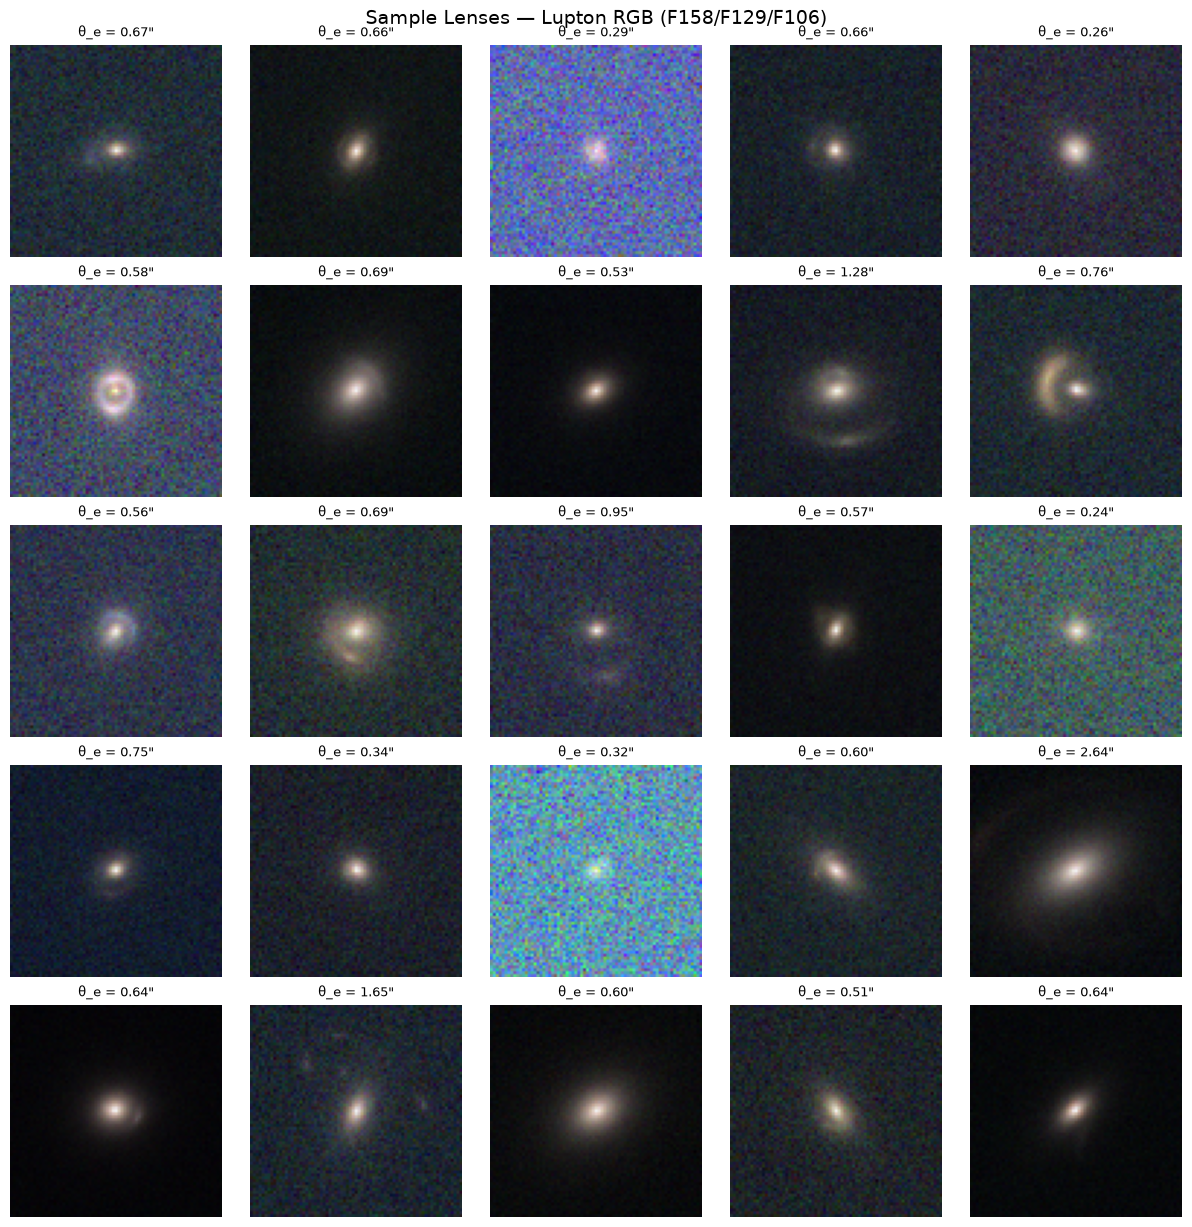

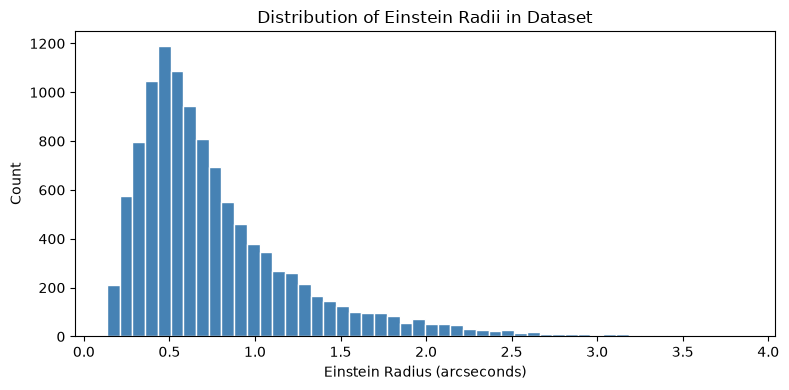

In [7]:
grid_size = 5
_, ax = plt.subplots(grid_size, grid_size, figsize=(12, 12), constrained_layout=True)

for i, (rgb, er) in enumerate(zip(rgb_previews[:grid_size**2], labels[:grid_size**2])):
    row, col = i // grid_size, i % grid_size
    ax[row, col].imshow(rgb)
    ax[row, col].set_title(f'θ_e = {er:.2f}"', fontsize=9)
    ax[row, col].axis('off')

plt.suptitle('Sample Lenses — Lupton RGB (F158/F129/F106)', fontsize=14, y=1.01)
plt.show()

# Also plot the distribution of Einstein radii
plt.figure(figsize=(8, 4))
plt.hist(labels, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Einstein Radius (arcseconds)')
plt.ylabel('Count')
plt.title('Distribution of Einstein Radii in Dataset')
plt.tight_layout()
plt.show()


---
## Cell 5: Data Augmentation

As recommended by Schaefer et al. (2018), we exploit the dihedral symmetry of gravitational lenses: rotations and a flip give 8 free variants of every training image.

In [8]:
def augment_dataset(images, labels):
    """
    Apply 8 dihedral transformations to every image.
    images: (N, 3, H, W)
    labels: (N,)
    Returns augmented arrays of shape (8N, 3, H, W) and (8N,)
    """
    aug_images, aug_labels = [], []

    for img, label in zip(images, labels):
        for k in range(4):                          # 0, 90, 180, 270 degrees
            rotated = np.rot90(img, k, axes=(1, 2)) # rotate on H, W axes
            aug_images.append(rotated.copy())
            aug_labels.append(label)

            flipped = np.flip(rotated, axis=2).copy()  # horizontal flip
            aug_images.append(flipped)
            aug_labels.append(label)

    return np.array(aug_images, dtype=np.float32), np.array(aug_labels, dtype=np.float32)


images_aug, labels_aug = augment_dataset(images, labels)

print(f'Original dataset  : {images.shape[0]:,} images')
print(f'Augmented dataset : {images_aug.shape[0]:,} images  (8× via dihedral symmetry)')


Original dataset  : 11,160 images
Augmented dataset : 89,280 images  (8× via dihedral symmetry)


---
## Cell 6: PyTorch Dataset and DataLoaders

70% training / 15% validation / 15% test.

In [9]:
class LensDataset(Dataset):
    """Simple PyTorch Dataset wrapping our numpy arrays."""
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


full_dataset = LensDataset(images_aug, labels_aug)
total = len(full_dataset)

n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples   : {n_train:,}')
print(f'Validation samples : {n_val:,}')
print(f'Test samples       : {n_test:,}')


Training samples   : 62,495
Validation samples : 13,392
Test samples       : 13,393


---
## Cell 7: Define the Residual CNN

This follows the ResNet-18-inspired pattern from C21 in the More et al. (2024) comparison paper: a stem convolution, followed by residual blocks, then global average pooling and a small FC head.

In [10]:
class ResidualBlock(nn.Module):
    """
    A single residual block: two 3x3 convs with batch norm and ReLU,
    plus a skip connection that adds the block's input back to its output.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out


class ResNetCNN(nn.Module):
    """
    Residual CNN regressor. The final layer is a single raw number
    (Linear(64, 1), no activation) — that number IS the predicted theta_e.

    Architecture:
        Input  : (batch, 3, 73, 73)
        Stem   : Conv(3->16) + BN + ReLU                  -> (batch, 16, 73, 73)
        Stage 1: ResidualBlock(16->32,  stride=2) x2       -> (batch, 32, 36, 36)
        Stage 2: ResidualBlock(32->64,  stride=2) x2       -> (batch, 64, 18, 18)
        Stage 3: ResidualBlock(64->128, stride=2) x2       -> (batch, 128, 9, 9)
        Stage 4: ResidualBlock(128->256,stride=2) x2       -> (batch, 256, 5, 5)
        Pool   : AdaptiveAvgPool2d(1)                      -> (batch, 256, 1, 1)
        FC head: 256 -> 64 -> 1
    """
    def __init__(self):
        super(ResNetCNN, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(16, 32, stride=2),
            ResidualBlock(32, 32, stride=1)
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64, stride=1)
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1)
        )
        self.stage4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1)
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.global_pool(x)
        x = self.fc_head(x)
        return x.squeeze(1)


# ── Instantiate the regressor ──────────────────────────────────────────────
model = ResNetCNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')


ResNetCNN(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 3

---
## Cell 8: Training Setup

**Loss:** Huber loss — behaves like MSE for small errors, like MAE for large ones, so a few huge outliers can't dominate the gradient.
**Optimizer:** Adam, lr `3e-4`. **Scheduler:** halves the LR after 9 stagnant epochs. **Early stopping:** stops after 18 stagnant epochs.

In [11]:
LEARNING_RATE = 3e-4
NUM_EPOCHS    = 150

HUBER_DELTA = 0.1

criterion = nn.HuberLoss(delta=HUBER_DELTA)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=9
)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


early_stopper = EarlyStopping(patience=18, min_delta=1e-5)

print(f'Loss      : Huber (delta={HUBER_DELTA})')
print(f'Optimizer : Adam  (lr={LEARNING_RATE})')
print(f'Max Epochs: {NUM_EPOCHS}  (early stopping patience={early_stopper.patience}, '
      f'scheduler patience={scheduler.patience})')
print(f'Batch     : {BATCH_SIZE}')


Loss      : Huber (delta=0.1)
Optimizer : Adam  (lr=0.0003)
Max Epochs: 150  (early stopping patience=18, scheduler patience=9)
Batch     : 64


---
## Cell 9: Training Loop

Trains `model` and saves the best weights (by validation loss) to `best_model_lensonly.pt`. This must run before the evaluation cells below — they load these saved weights rather than retraining.

In [12]:
train_losses = []
val_losses   = []
best_val_loss = float('inf')

early_stopper.best_loss = float('inf')
early_stopper.counter = 0
early_stopper.should_stop = False

for epoch in range(NUM_EPOCHS):

    model.train()
    running_train_loss = 0.0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        predictions = model(images_batch)
        loss = criterion(predictions, labels_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * len(images_batch)

    avg_train_loss = running_train_loss / n_train

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)
            predictions  = model(images_batch)
            loss = criterion(predictions, labels_batch)
            running_val_loss += loss.item() * len(images_batch)

    avg_val_loss = running_val_loss / n_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model_lensonly.pt')

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f'  → Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}')

    if (epoch + 1) % 5 == 0:
        train_rmse = np.sqrt(avg_train_loss)
        val_rmse   = np.sqrt(avg_val_loss)
        print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS} — '
              f'Train RMSE: {train_rmse:.4f}"  |  '
              f'Val RMSE: {val_rmse:.4f}"  |  '
              f'EarlyStop counter: {early_stopper.counter}/{early_stopper.patience}')

    if early_stopper.step(avg_val_loss):
        print(f'\nEarly stopping triggered at epoch {epoch+1} '
              f'(no improvement for {early_stopper.patience} epochs).')
        print(f'Best validation loss (MSE): {early_stopper.best_loss:.6f}')
        break

print(f'\nBest validation loss (MSE): {best_val_loss:.6f}')
print(f'Best validation RMSE      : {np.sqrt(best_val_loss):.4f} arcseconds')


Epoch   5/150 — Train RMSE: 0.0782"  |  Val RMSE: 0.0664"  |  EarlyStop counter: 0/18
Epoch  10/150 — Train RMSE: 0.0712"  |  Val RMSE: 0.0612"  |  EarlyStop counter: 1/18
Epoch  15/150 — Train RMSE: 0.0662"  |  Val RMSE: 0.0592"  |  EarlyStop counter: 0/18
Epoch  20/150 — Train RMSE: 0.0640"  |  Val RMSE: 0.0569"  |  EarlyStop counter: 3/18
Epoch  25/150 — Train RMSE: 0.0614"  |  Val RMSE: 0.0550"  |  EarlyStop counter: 1/18
Epoch  30/150 — Train RMSE: 0.0603"  |  Val RMSE: 0.0567"  |  EarlyStop counter: 4/18
  → Learning rate reduced: 3.00e-04 → 1.50e-04
Epoch  35/150 — Train RMSE: 0.0591"  |  Val RMSE: 0.0564"  |  EarlyStop counter: 9/18
Epoch  40/150 — Train RMSE: 0.0560"  |  Val RMSE: 0.0529"  |  EarlyStop counter: 2/18
Epoch  45/150 — Train RMSE: 0.0551"  |  Val RMSE: 0.0531"  |  EarlyStop counter: 4/18
Epoch  50/150 — Train RMSE: 0.0547"  |  Val RMSE: 0.0540"  |  EarlyStop counter: 0/18
Epoch  55/150 — Train RMSE: 0.0540"  |  Val RMSE: 0.0532"  |  EarlyStop counter: 5/18
Epoch  

---
## Cell 10: Plot Training History

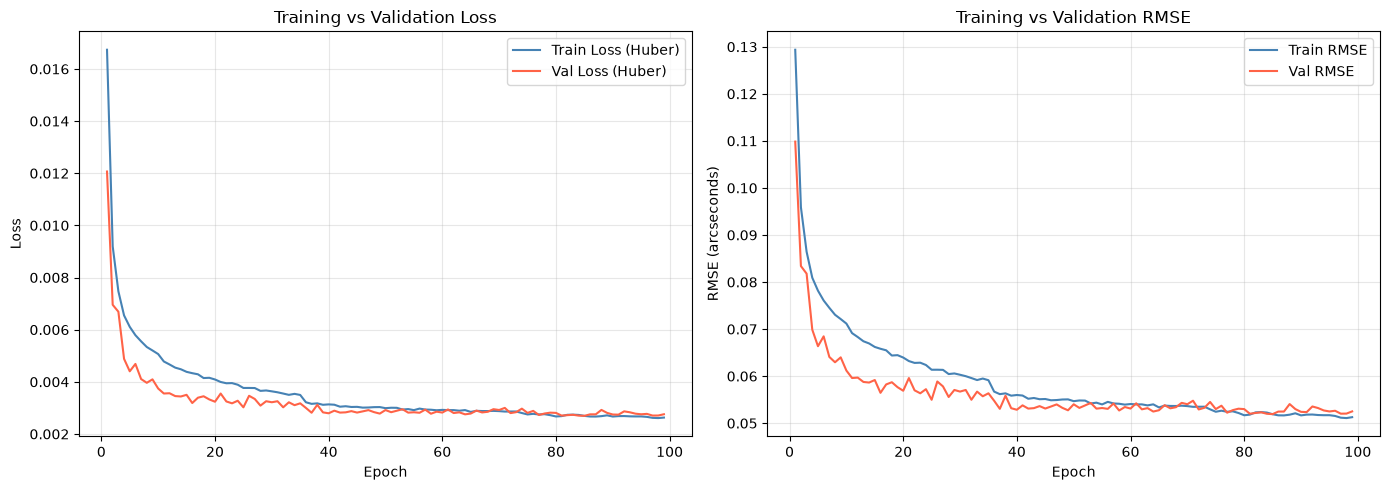

In [13]:
epochs = range(1, epoch+2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label='Train Loss (Huber)', color='steelblue')
axes[0].plot(epochs, val_losses,   label='Val Loss (Huber)',   color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, np.sqrt(train_losses), label='Train RMSE', color='steelblue')
axes[1].plot(epochs, np.sqrt(val_losses),   label='Val RMSE',   color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (arcseconds)')
axes[1].set_title('Training vs Validation RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Cell 11: Evaluate on Test Set

In [14]:
model.load_state_dict(torch.load('best_model_lensonly.pt', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        preds = model(images_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_mse  = np.mean((all_preds - all_labels) ** 2)
test_rmse = np.sqrt(test_mse)
test_mae  = np.mean(np.abs(all_preds - all_labels))
test_r2   = r2_score(all_labels, all_preds)

print('── Test Set Results ──────────────────────────────')
print(f'RMSE : {test_rmse:.4f} arcseconds')
print(f'MAE  : {test_mae:.4f} arcseconds')
print(f'R²   : {test_r2:.4f}')
print('──────────────────────────────────────────────────')
print()
print('Interpretation:')
print(f'  On average, predictions are off by ~{test_rmse:.3f} arcseconds')
print(f'  R² of {test_r2:.3f} means the model explains {test_r2*100:.1f}% of the variance in Einstein radius')


── Test Set Results ──────────────────────────────
RMSE : 0.1190 arcseconds
MAE  : 0.0512 arcseconds
R²   : 0.9447
──────────────────────────────────────────────────

Interpretation:
  On average, predictions are off by ~0.119 arcseconds
  R² of 0.945 means the model explains 94.5% of the variance in Einstein radius


---
## Cell 12: Visualize Predictions

Predicted vs true scatter, and residuals.

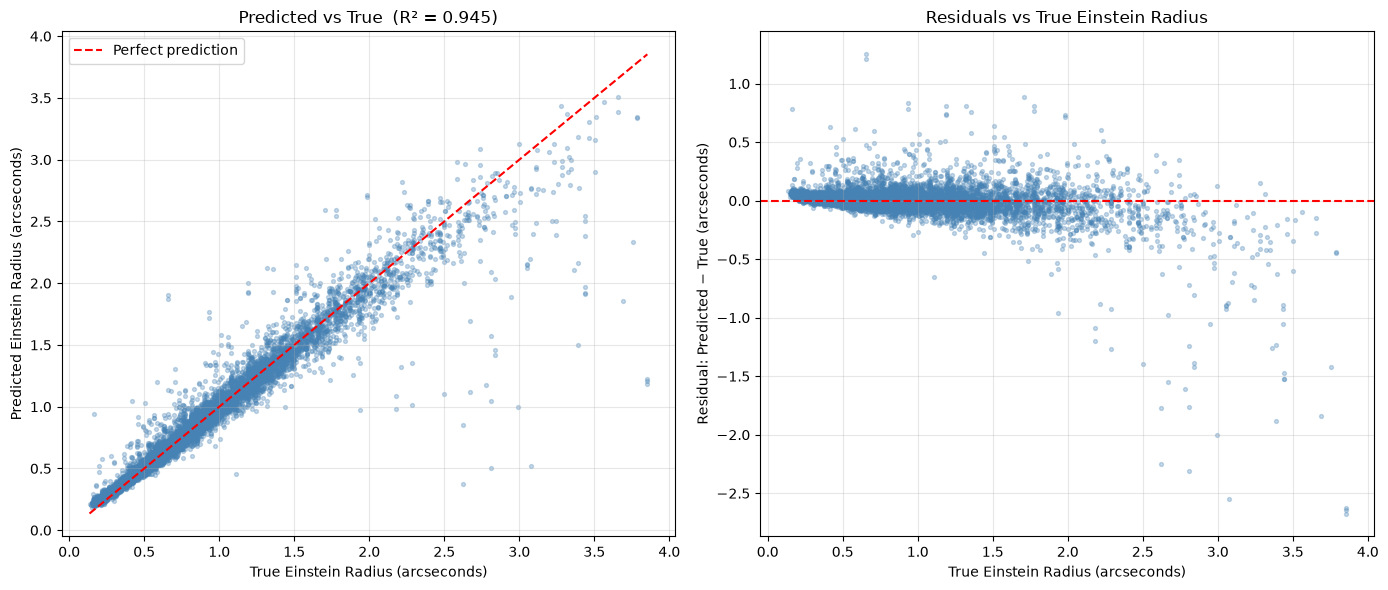

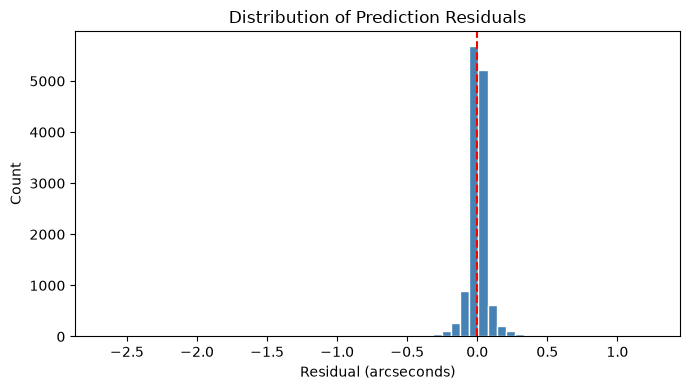

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(all_labels, all_preds, alpha=0.3, s=8, color='steelblue')
lims = [all_labels.min(), all_labels.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('True Einstein Radius (arcseconds)')
axes[0].set_ylabel('Predicted Einstein Radius (arcseconds)')
axes[0].set_title(f'Predicted vs True  (R² = {test_r2:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = all_preds - all_labels
axes[1].scatter(all_labels, residuals, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('True Einstein Radius (arcseconds)')
axes[1].set_ylabel('Residual: Predicted − True (arcseconds)')
axes[1].set_title('Residuals vs True Einstein Radius')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (arcseconds)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Residuals')
plt.tight_layout()
plt.show()


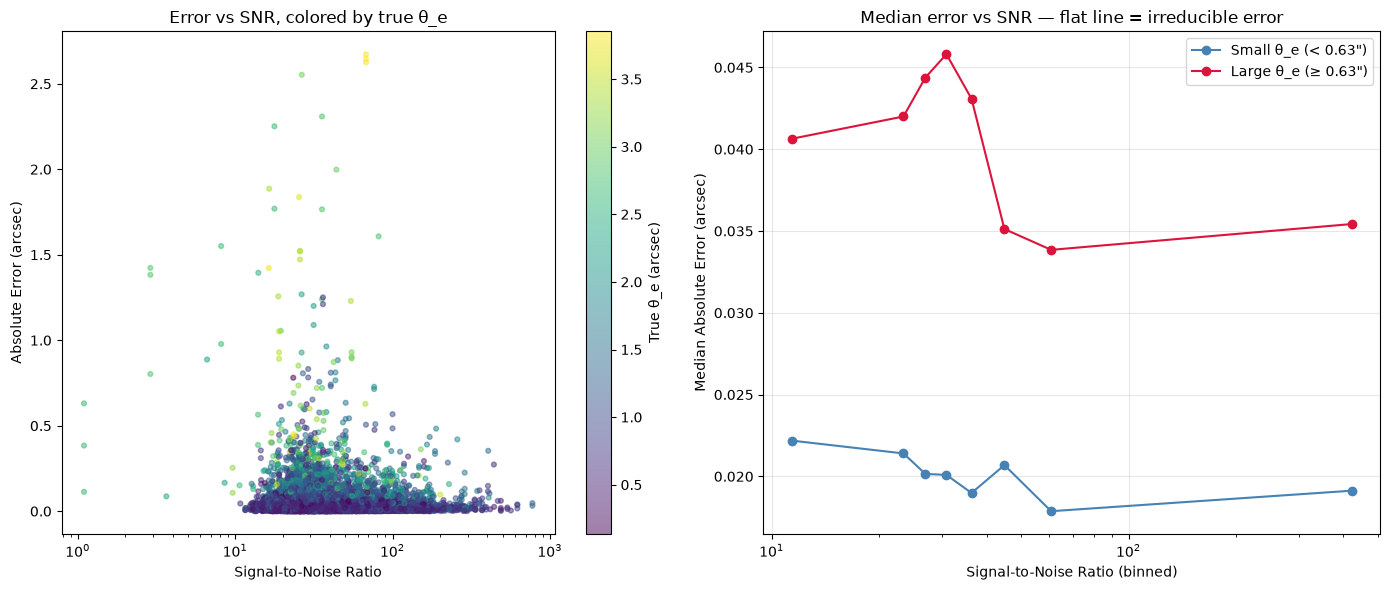

In [16]:
# ── Error vs SNR ─────────────────────────────────────────────────────────────
test_indices = test_set.indices
orig_indices_full = np.array([idx // 8 for idx in test_indices])

test_snr = snr_values[orig_indices_full]
abs_error = np.abs(all_preds - all_labels)

theta_e_median = np.median(all_labels)
is_large_theta_e = all_labels >= theta_e_median

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(test_snr, abs_error, c=all_labels, cmap='viridis',
                      alpha=0.5, s=12)
axes[0].set_xlabel('Signal-to-Noise Ratio')
axes[0].set_ylabel('Absolute Error (arcsec)')
axes[0].set_xscale('log')
axes[0].set_title('Error vs SNR, colored by true θ_e')
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('True θ_e (arcsec)')

n_bins = 8
snr_bin_edges = np.percentile(test_snr, np.linspace(0, 100, n_bins + 1))
snr_bin_centers = 0.5 * (snr_bin_edges[:-1] + snr_bin_edges[1:])

for mask, label, color in [(~is_large_theta_e, f'Small θ_e (< {theta_e_median:.2f}")', 'steelblue'),
                             (is_large_theta_e, f'Large θ_e (≥ {theta_e_median:.2f}")', 'crimson')]:
    binned_median_error = []
    for i in range(n_bins):
        in_bin = mask & (test_snr >= snr_bin_edges[i]) & (test_snr < snr_bin_edges[i + 1])
        if in_bin.sum() > 0:
            binned_median_error.append(np.median(abs_error[in_bin]))
        else:
            binned_median_error.append(np.nan)
    axes[1].plot(snr_bin_centers, binned_median_error, 'o-', color=color, label=label)

axes[1].set_xlabel('Signal-to-Noise Ratio (binned)')
axes[1].set_ylabel('Median Absolute Error (arcsec)')
axes[1].set_xscale('log')
axes[1].set_title('Median error vs SNR — flat line = irreducible error')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
def get_worst_predictions(all_preds, all_labels, orig_indices_full, n_worst=25):
    """
    Returns a DataFrame of the n_worst predictions by absolute error, with
    columns for prediction, truth, error, and the original lens index.
    """
    import pandas as pd
    abs_errors = np.abs(all_preds - all_labels)
    worst_order = np.argsort(abs_errors)[::-1][:n_worst]

    df = pd.DataFrame({
        'test_pos':       worst_order,
        'orig_idx':       orig_indices_full[worst_order],
        'pred':           all_preds[worst_order],
        'truth':          all_labels[worst_order],
        'abs_error':      abs_errors[worst_order],
        'signed_error':   (all_preds - all_labels)[worst_order],
    })
    return df


def attach_physical_properties(worst_df, labels, snr_values=None, system_names=None):
    """Joins metadata onto the worst-prediction DataFrame using orig_idx."""
    idx = worst_df['orig_idx'].values

    worst_df['theta_e_true'] = labels[idx]

    if snr_values is not None:
        worst_df['snr'] = snr_values[idx]

    if system_names is not None:
        worst_df['system_name'] = system_names[idx]

    worst_df['pct_error'] = 100 * worst_df['abs_error'] / worst_df['truth']

    return worst_df


def print_worst_summary(worst_df, n_show=25):
    """Pretty-print the worst predictions table for quick eyeballing."""
    cols_priority = ['system_name', 'orig_idx', 'truth', 'pred', 'abs_error', 'pct_error',
                      'theta_e_true', 'snr']
    cols = [c for c in cols_priority if c in worst_df.columns]
    cols += [c for c in worst_df.columns if c not in cols and c not in
             ('test_pos', 'signed_error')]

    print(f'\n── Worst {n_show} Predictions by Absolute Error ─────────────────────')
    print(worst_df[cols].head(n_show).to_string(index=False, float_format='%.4f'))

    if 'theta_e_true' in worst_df.columns:
        print(f'\nWorst-{n_show} theta_e stats:')
        print(f"  mean={worst_df['theta_e_true'].head(n_show).mean():.3f}  "
              f"median={worst_df['theta_e_true'].head(n_show).median():.3f}  "
              f"min={worst_df['theta_e_true'].head(n_show).min():.3f}  "
              f"max={worst_df['theta_e_true'].head(n_show).max():.3f}")


def plot_worst_images(worst_df, rgb_previews, n_show=12, cols=3, panel_size=5):
    """Grid of the worst-predicted lenses, using the Lupton RGB previews."""
    n_show = min(n_show, len(worst_df))
    rows = int(np.ceil(n_show / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(panel_size * cols, panel_size * rows))
    axes = np.atleast_1d(axes).flatten()

    for i, (_, r) in enumerate(worst_df.head(n_show).iterrows()):
        orig_idx = int(r['orig_idx'])
        preview = rgb_previews[orig_idx]

        snr_str = '  snr={:.1f}'.format(r['snr']) if 'snr' in worst_df.columns else ''
        pct_err_str = '  err={:.1f}%'.format(r['pct_error']) if 'pct_error' in worst_df.columns else ''

        ax = axes[i]
        ax.imshow(preview)
        ax.axis('off')

        title = f"pred={r['pred']:.3f}\"  true={r['truth']:.3f}\"{pct_err_str}{snr_str}"
        ax.set_title(title, fontsize=10)

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.suptitle('Worst Predictions — Lupton RGB (F158/F129/F106)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()



── Worst 25 Predictions by Absolute Error ─────────────────────
 orig_idx  truth   pred  abs_error  pct_error  theta_e_true     snr
     5617 3.8532 1.1800     2.6732    69.3765        3.8532 67.8885
     5617 3.8532 1.2079     2.6452    68.6508        3.8532 67.8885
     5617 3.8532 1.2275     2.6257    68.1430        3.8532 67.8885
      267 3.0750 0.5221     2.5528    83.0194        3.0750 26.5184
     4165 2.8112 0.5025     2.3087    82.1253        2.8112 35.6622
      355 2.6226 0.3711     2.2515    85.8496        2.6226 17.7698
     1901 2.9916 0.9936     1.9980    66.7877        2.9916 44.0120
     3931 3.3899 1.5036     1.8864    55.6460        3.3899 16.4558
    10084 3.6892 1.8522     1.8371    49.7951        3.6892 25.5016
      355 2.6226 0.8531     1.7695    67.4722        2.6226 17.7698
     4165 2.8112 1.0453     1.7658    62.8150        2.8112 35.6622
      174 2.7812 1.1735     1.6077    57.8057        2.7812 81.6325
     5786 2.6692 1.1185     1.5508    58.0978      

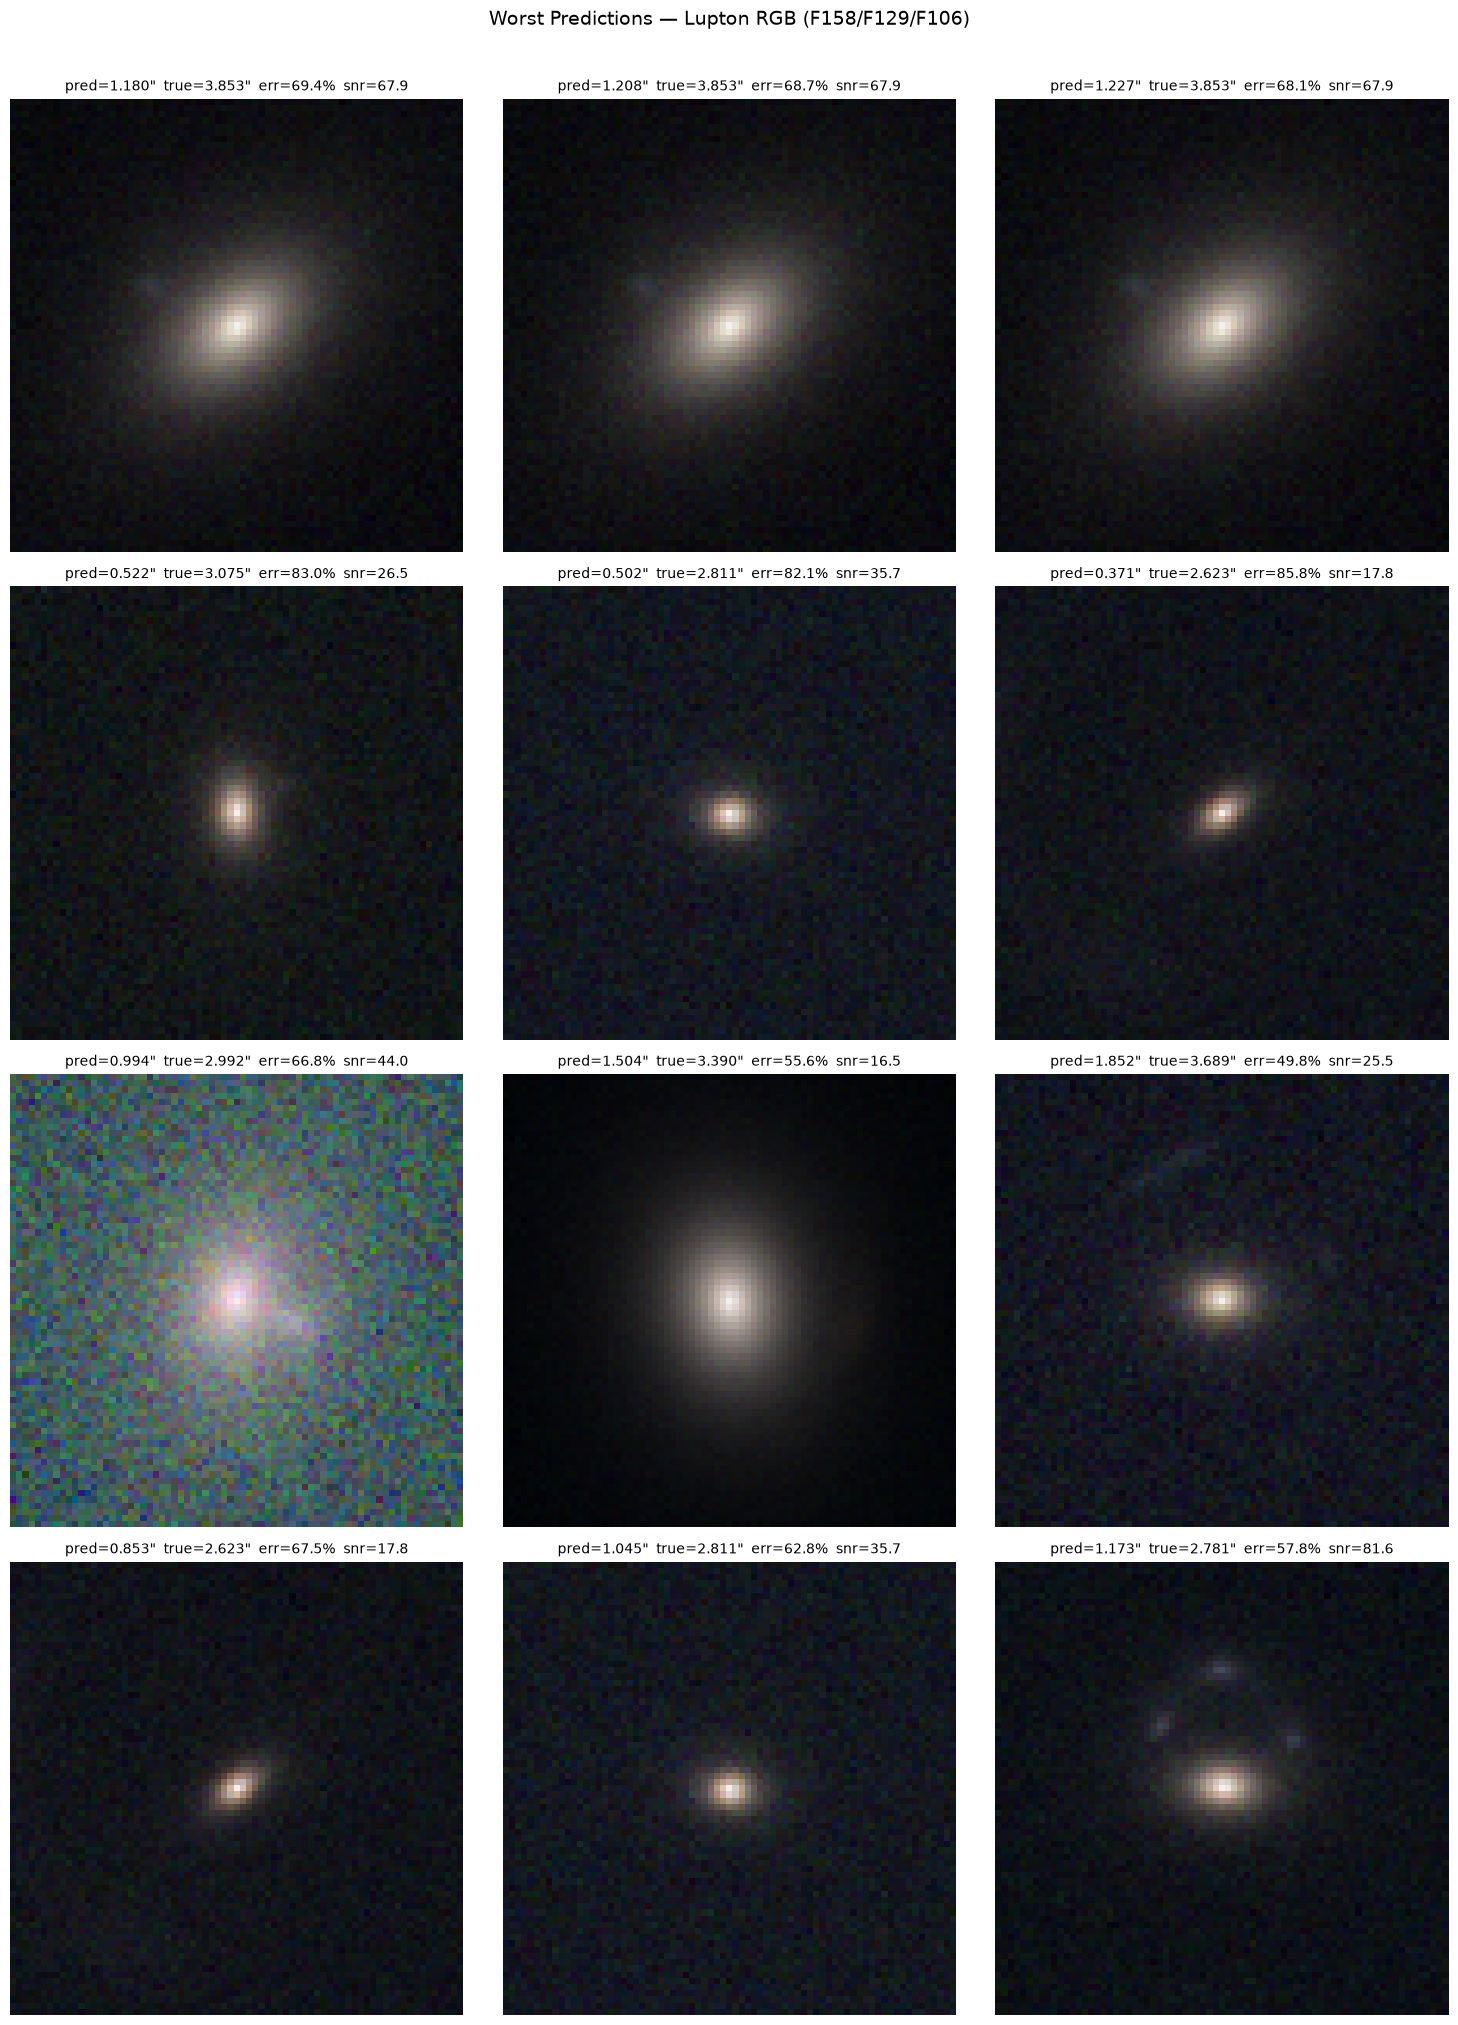

In [18]:
worst_df = get_worst_predictions(all_preds, all_labels, orig_indices_full, n_worst=25)
worst_df = attach_physical_properties(worst_df, labels, snr_values=snr_values)
print_worst_summary(worst_df, n_show=25)
plot_worst_images(worst_df, rgb_previews, n_show=12, cols=3, panel_size=5)


Test set θ_e range: 0.135" to 3.853"
Quartile edges: [0.13509311 0.44345504 0.63001442 0.9619835  3.86315561]

── R² and Error Metrics by Einstein Radius Quartile ────────────────────
Bin                  Range (arcsec)            N     RMSE      MAE       R²
───────────────────────────────────────────────────────────────────────────
Q1 (smallest θ_e)    0.135–0.443            3347   0.0426   0.0288   0.6773
Q2                   0.443–0.630            3349   0.0447   0.0261   0.2819
Q3                   0.630–0.962            3348   0.0713   0.0414   0.4185
Q4 (largest θ_e)     0.962–3.863            3349   0.2184   0.1084   0.8143
───────────────────────────────────────────────────────────────────────────


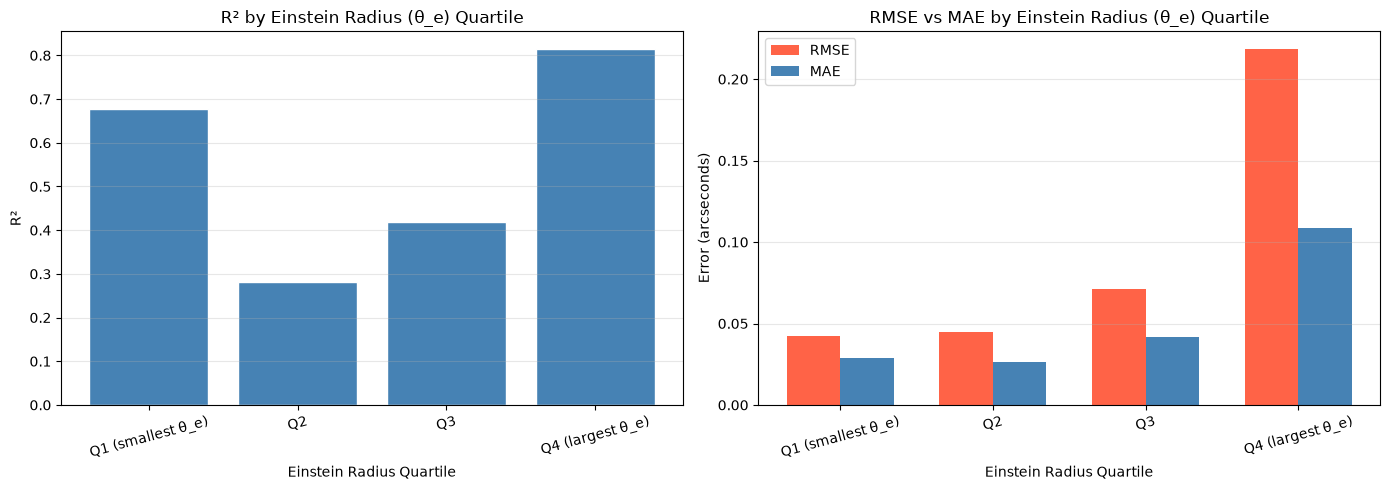

In [19]:
theta_e_bin_edges = np.percentile(all_labels, [0, 25, 50, 75, 100])
theta_e_bin_edges[-1] += 0.01
theta_e_bin_labels = ['Q1 (smallest θ_e)', 'Q2', 'Q3', 'Q4 (largest θ_e)']

print(f'Test set θ_e range: {all_labels.min():.3f}" to {all_labels.max():.3f}"')
print(f'Quartile edges: {theta_e_bin_edges}')

print('\n── R² and Error Metrics by Einstein Radius Quartile ────────────────────')
print(f'{"Bin":<20} {"Range (arcsec)":<20} {"N":>6} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('─' * 75)

bin_results = []
for i in range(len(theta_e_bin_edges) - 1):
    lo, hi = theta_e_bin_edges[i], theta_e_bin_edges[i + 1]
    mask = (all_labels >= lo) & (all_labels < hi)
    n_in_bin = mask.sum()

    if n_in_bin < 5:
        print(f'{theta_e_bin_labels[i]:<20} {"":<20} {n_in_bin:>6}    (too few samples)')
        continue

    bin_preds  = all_preds[mask]
    bin_truth  = all_labels[mask]

    bin_rmse = np.sqrt(np.mean((bin_preds - bin_truth) ** 2))
    bin_mae  = np.mean(np.abs(bin_preds - bin_truth))
    bin_r2   = r2_score(bin_truth, bin_preds)

    range_str = f'{lo:.3f}–{hi:.3f}'
    bin_results.append({
        'bin': theta_e_bin_labels[i], 'range': range_str, 'n': n_in_bin,
        'rmse': bin_rmse, 'mae': bin_mae, 'r2': bin_r2
    })

    print(f'{theta_e_bin_labels[i]:<20} {range_str:<20} {n_in_bin:>6} {bin_rmse:>8.4f} {bin_mae:>8.4f} {bin_r2:>8.4f}')

print('─' * 75)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_plotted = [r['bin']  for r in bin_results]
r2_plotted   = [r['r2']   for r in bin_results]
rmse_plotted = [r['rmse'] for r in bin_results]
mae_plotted  = [r['mae']  for r in bin_results]

axes[0].bar(bins_plotted, r2_plotted, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Einstein Radius Quartile')
axes[0].set_ylabel('R²')
axes[0].set_title('R² by Einstein Radius (θ_e) Quartile')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(alpha=0.3, axis='y')

x = np.arange(len(bins_plotted))
width = 0.35
axes[1].bar(x - width/2, rmse_plotted, width, label='RMSE', color='tomato')
axes[1].bar(x + width/2, mae_plotted,  width, label='MAE',  color='steelblue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bins_plotted, rotation=15)
axes[1].set_xlabel('Einstein Radius Quartile')
axes[1].set_ylabel('Error (arcseconds)')
axes[1].set_title('RMSE vs MAE by Einstein Radius (θ_e) Quartile')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


---
## Cell 13: Inspect Individual Predictions

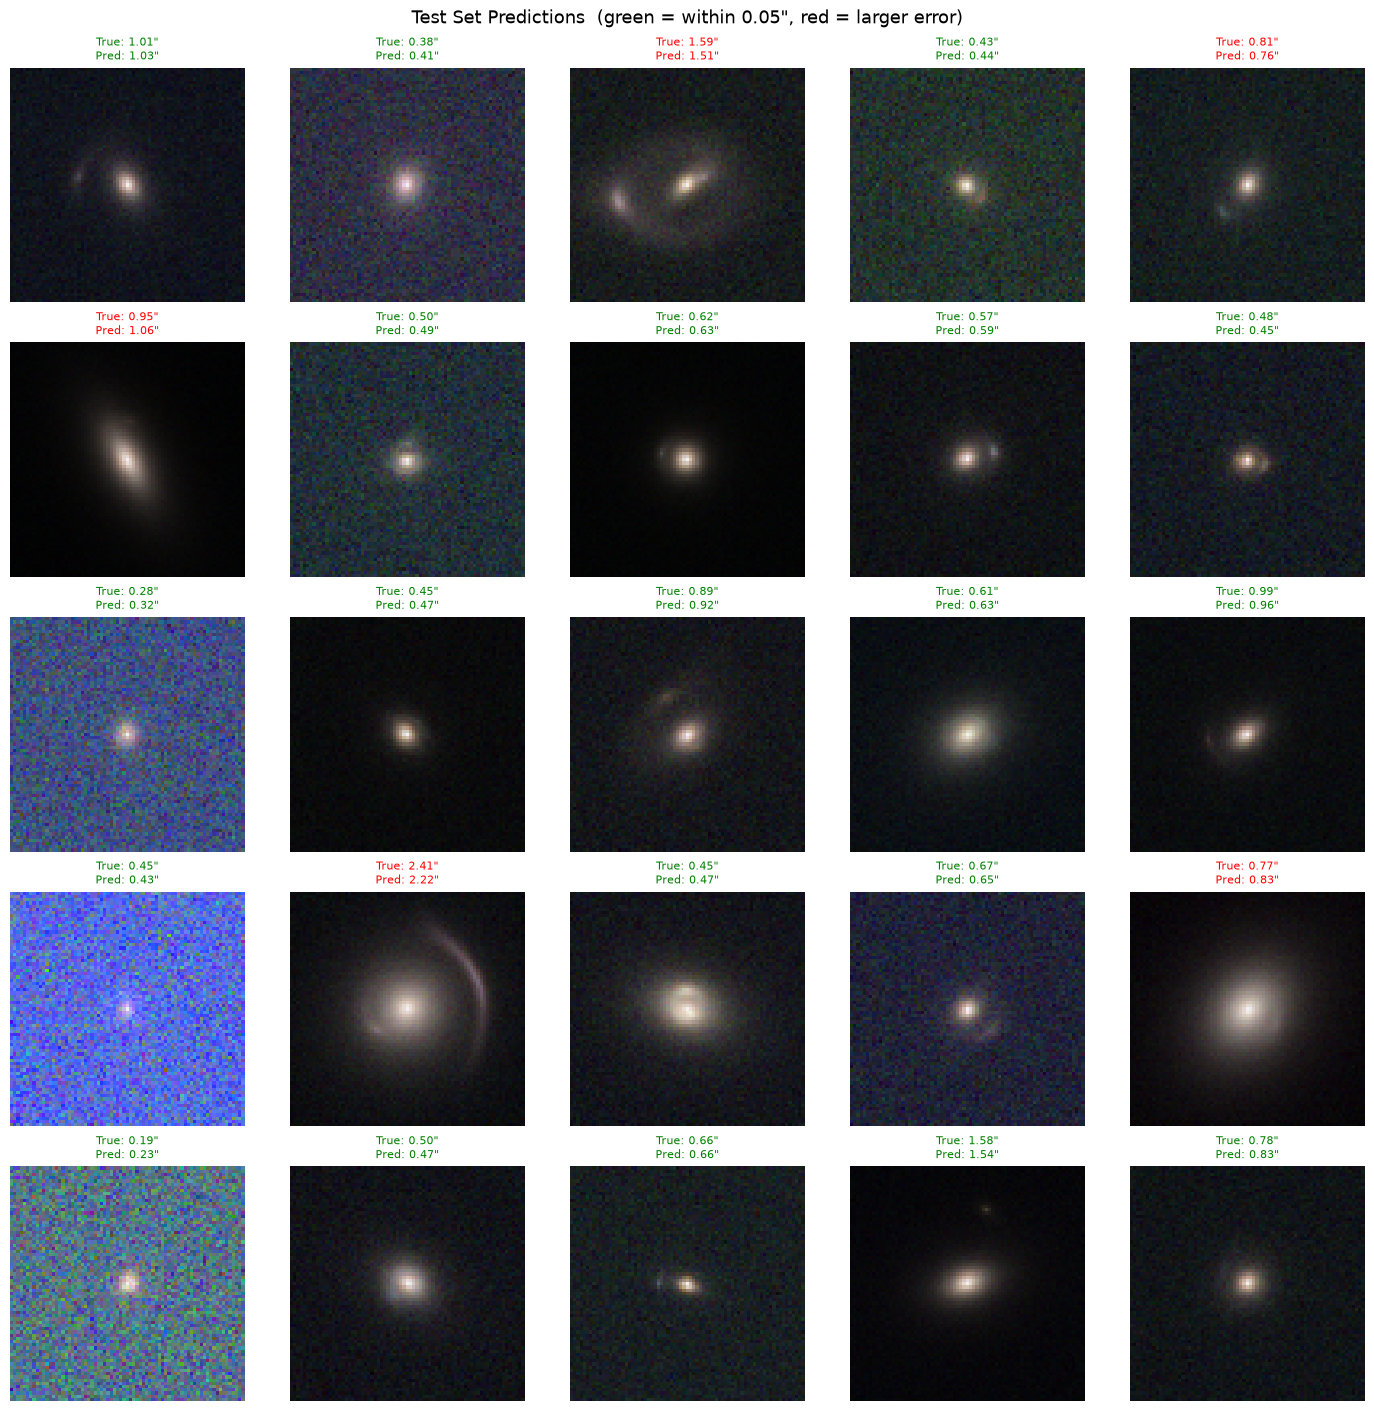

In [20]:
test_indices = test_set.indices
orig_indices = [idx // 8 for idx in test_indices[:25]]

fig, axes = plt.subplots(5, 5, figsize=(14, 14), constrained_layout=True)

for i, (orig_idx, pred, true) in enumerate(zip(orig_indices, all_preds[:25], all_labels[:25])):
    row, col = i // 5, i % 5
    axes[row, col].imshow(rgb_previews[orig_idx])
    axes[row, col].set_title(
        f'True: {true:.2f}"\nPred: {pred:.2f}"',
        fontsize=8,
        color='green' if abs(pred - true) < 0.05 else 'red'
    )
    axes[row, col].axis('off')

plt.suptitle('Test Set Predictions  (green = within 0.05", red = larger error)', fontsize=13)
plt.show()


In [21]:
THRESHOLD = 0.05

correct = np.abs(all_preds - all_labels) < THRESHOLD
pct_correct = 100 * np.mean(correct)

print(f'Correct (within {THRESHOLD}"): {correct.sum()} / {len(all_labels)}')
print(f'Percentage correct: {pct_correct:.2f}%')


Correct (within 0.05"): 9795 / 13393
Percentage correct: 73.14%


---
## Summary

### What this notebook does
| Step | Description |
|---|---|
| Data loading | Opens the `.h5` file and builds the lens-only regression dataset |
| Augmentation | 8× dihedral symmetry (rotations + flip) |
| Training | Trains `model` (ResNetCNN + Huber loss) to predict θ_e |
| Evaluation | RMSE/MAE/R² on the test set, error vs. SNR, worst predictions, performance by Einstein radius quartile |

### Run order
Run every cell top to bottom once. The training loop takes a while and only needs to run once per session — after that, the saved `best_model_lensonly.pt` weights are what the evaluation cells use.

### If R² looks low
Check the error-vs-SNR plot — low-SNR images are usually the hardest to fit — and look at the worst-predictions table to see whether errors cluster around a particular θ_e range or SNR band.